In [1]:
# --- Cell 1: imports + shared config ---
%load_ext autoreload
%autoreload 2
import sys, torch, numpy as np
sys.path.append('..')
sys.path.append('../..')

from common.seed import set_seed
from common.io_utils import save_results, load_results
from shared.pacs_protocol import build_loaders
from task2.backbones.backbone import PACSModel
from task2.training.train_loop import train_model
from task2.methods.source_only import SourceOnly

set_seed(6304)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

CFG = dict(seed=6304, num_classes=7,
           batch_per_source=8, target_batch=24, eval_batch=64, num_workers=2,
           max_epochs=30, patience=5, lr=1e-4, weight_decay=1e-4, amp=True)
DATA_ROOT = '../../datasets/PACS'
print(device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')

cuda NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# --- Cell 2: loaders from the frozen splits ---
splits = load_results('../../shared/splits/pacs_sketch_seed6304.json')
loaders = build_loaders(DATA_ROOT, splits,
                        batch_per_source=CFG['batch_per_source'],
                        target_batch=CFG['target_batch'],
                        eval_batch=CFG['eval_batch'],
                        num_workers=CFG['num_workers'], seed=CFG['seed'])
print(f"source train imgs={loaders['n_source_train']}  target imgs={loaders['n_target']}")
print(f"steps/epoch={loaders['steps_per_epoch']}  (24 source images per step)")

source train imgs=4849  target imgs=3929
steps/epoch=203  (24 source images per step)


In [3]:
# --- Cell 3: VERIFICATION —  ---
from task2.backbones.backbone import set_train_mode
import torch.nn.functional as F
from shared.pacs_protocol import next_source_batch

probe = PACSModel(num_classes=7).to(device)
bn = [m for m in probe.modules() if isinstance(m, torch.nn.BatchNorm2d)]
before = bn[0].running_mean.clone()

set_train_mode(probe)
x, y = next_source_batch(loaders['source_train'], device)
F.cross_entropy(probe(x)[0], y).backward()          # one full forward+backward

after = bn[0].running_mean
print('BN modules:', len(bn), '| all in eval mode:', all(not m.training for m in bn))
print('running_mean changed:', not torch.allclose(before, after))   # must be False
print('gamma still trainable:', bn[0].weight.requires_grad)          # must be True
del probe, x, y; torch.cuda.empty_cache()

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\javai/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:09<00:00, 5.15MB/s]


BN modules: 20 | all in eval mode: True
running_mean changed: False
gamma still trainable: True


In [4]:
# --- Cell 4: train source-only ERM ---
set_seed(6304)                       # re-seed so the model init is reproducible
model = PACSModel(num_classes=CFG['num_classes']).to(device)
method = SourceOnly(CFG)

out = train_model(model, method, loaders, CFG, device,
                  ckpt_path='../../datasets/cache/task2_source_only.pt')
print(out['best_epoch'], out['best_mean_macro_f1'], f"{out['minutes']:.1f} min")

ep01 loss_total=0.5063 loss_cls=0.5063 train_acc=0.8206 | val photo=0.934 art_painting=0.823 cartoon=0.910 mean_f1=0.8889 | 80s
ep02 loss_total=0.2314 loss_cls=0.2314 train_acc=0.9226 | val photo=0.942 art_painting=0.833 cartoon=0.903 mean_f1=0.8926 | 161s
ep03 loss_total=0.1496 loss_cls=0.1496 train_acc=0.9491 | val photo=0.961 art_painting=0.870 cartoon=0.905 mean_f1=0.9122 | 206s
ep04 loss_total=0.1330 loss_cls=0.1330 train_acc=0.9579 | val photo=0.957 art_painting=0.896 cartoon=0.933 mean_f1=0.9287 | 252s
ep05 loss_total=0.1068 loss_cls=0.1068 train_acc=0.9633 | val photo=0.928 art_painting=0.866 cartoon=0.911 mean_f1=0.9017 | 304s
ep06 loss_total=0.1033 loss_cls=0.1033 train_acc=0.9655 | val photo=0.961 art_painting=0.875 cartoon=0.962 mean_f1=0.9327 | 353s
ep07 loss_total=0.0948 loss_cls=0.0948 train_acc=0.9694 | val photo=0.961 art_painting=0.884 cartoon=0.944 mean_f1=0.9295 | 401s
ep08 loss_total=0.0758 loss_cls=0.0758 train_acc=0.9752 | val photo=0.944 art_painting=0.877 carto

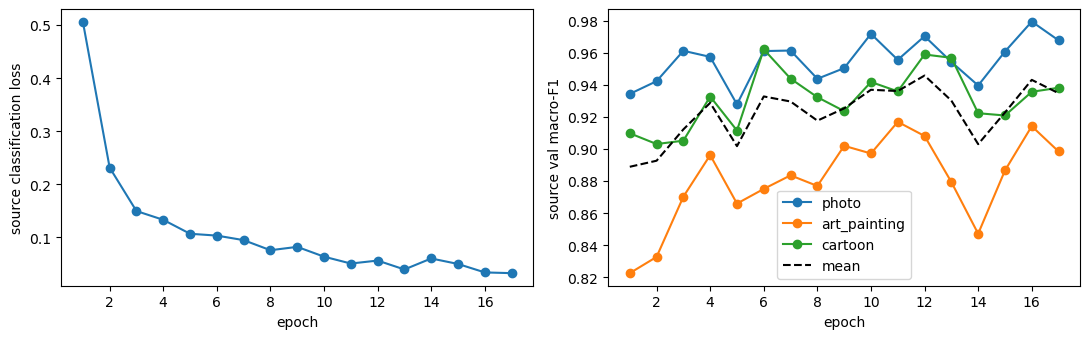

In [5]:
# --- Cell 5: save results  ---
results = {'step': 'source_only', 'seed': 6304, 'method': 'source_only',
           'config': CFG, 'steps_per_epoch': loaders['steps_per_epoch'],
           'best_epoch': out['best_epoch'],
           'best_mean_macro_f1': out['best_mean_macro_f1'],
           'source_val_at_best': out['source_val_at_best'],
           'minutes': out['minutes'], 'history': out['history']}
save_results(results, '../results/source_only.json')

import matplotlib.pyplot as plt
h = out['history']
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot([r['epoch'] for r in h], [r['loss_cls'] for r in h], marker='o')
ax[0].set_xlabel('epoch'); ax[0].set_ylabel('source classification loss')
for d in splits['source_domains']:
    ax[1].plot([r['epoch'] for r in h], [r['per_domain'][d]['macro_f1'] for r in h],
               marker='o', label=d)
ax[1].plot([r['epoch'] for r in h], [r['mean_macro_f1'] for r in h],
           'k--', label='mean')
ax[1].set_xlabel('epoch'); ax[1].set_ylabel('source val macro-F1'); ax[1].legend()
plt.tight_layout(); plt.savefig('../../report/figures/task2_source_only_curves.png', dpi=200)
plt.show()